# Introduction: Deforestation Risk Classification (LDA vs. Decision Trees)
This notebook builds upon our ongoing analysis of the global deforestation dataset. The data has been previously cleaned, preprocessed, and engineered to include a distinct classification variable. This target variable was created based on the probability thresholds established in my previous Logistic Classifier Project.

While the logistic approach provided a strong baseline, our goal here is to put two very different algorithms to the test: Linear Discriminant Analysis (LDA) and Decision Trees. We will compare them head-to-head to evaluate not only their raw predictive power but also their inference power (how well they explain the behavioral "why" behind the risk).

**Target Variable and Data Splitting Strategy**
- The Output Variable: Our target is a binary classification representing Deforestation Risk: Class 0 (Low Risk) and Class 1 (High Risk).

- Class Balance: The dataset is moderately imbalanced, with roughly 70% Low Risk and 30% High Risk countries. 

-  Train/Test Split & Stratification: To rigorously evaluate these models, the data is divided into a 80 & 20 training and testing split. Because of the class distribution, it is absolutely critical that this split is performed using stratification (stratify=y).
    - Why is this balance important? Preserving the exact proportion of Low/High Risk classes in both the training and testing subsets ensures a fair evaluation. If we split the data completely randomly, we risk training the model on an unrepresentative sample (e.g., too many "Low Risk" countries). Stratification prevents the model from developing a majority-class bias, ensuring that our final evaluation metrics (like the F1-Score) accurately reflect the model's real-world ability to detect critical deforestation threats.

Now, in this notebook, we will leverage data visualizations, mathematical modeling, performance metrics, and class separation techniques to rigorously evaluate and compare our classification algorithms.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_score, recall_score,
    f1_score, roc_curve, auc, accuracy_score, classification_report
)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier

In [4]:
# csv path
path = './classified_deforestation_df.csv'

# convert to a dataframe
df = pd.read_csv(path)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

df.head()

,Density\n(P/Km2),Agricultural Land( %),Armed Forces size,Co2-Emissions,CPI,Gasoline Price,GDP,Gross primary education enrollment (%),Gross tertiary education enrollment (%),Infant mortality,Minimum wage,Out of pocket health expenditure,Physicians per thousand,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population,Latitude,Longitude,Deforestation_Critical
0,2.944439,17.4,12.666660,11.918437,5.026246,0.28,25.858995,109.9,51.4,3.049273,0.667829,28.1,1.72,41.2,37.2,66.100,11.70,17.265819,28.033886,1.659626,0
1,3.295837,47.5,11.669938,10.454322,5.571127,0.97,25.273298,113.5,9.3,3.962716,0.536493,33.4,0.21,77.5,9.2,49.100,6.89,16.862935,-11.202692,17.873887,1
2,2.890372,54.3,11.561725,12.212795,5.454252,1.10,26.831765,109.7,90.0,2.282382,1.470176,17.6,3.96,61.3,10.1,104.955,9.79,17.537331,-38.416097,-63.616672,1
3,4.700480,32.4,9.952325,11.025963,4.779628,1.20,26.824290,103.1,85.1,1.360977,2.311148,17.9,5.17,60.7,25.4,51.400,4.67,15.463095,47.516231,14.550072,0
4,7.714231,11.1,9.852247,10.363914,4.775672,0.43,24.375846,99.4,50.5,1.960095,1.213725,25.1,0.93,73.4,4.2,13.800,0.71,14.198805,26.066700,50.557700,0


To start off, it is always appropriate to define and review the target variable using `value_counts()`. This lets us understand the class distribution before the train-test split, the stratification strategy, and whether we are dealing with a balanced or imbalanced dataset.

In [5]:
# define target
y = df['Deforestation_Critical']

# check for data balance
y.value_counts()

Deforestation_Critical
0    72
1    31
Name: count, dtype: int64

The `value_counts()` output shows a class imbalance we are already familiar with from the previous project — 72 countries are non-critical (0) and 31 are critical (1), roughly a 70/30 split.

This imbalance has two direct consequences: first, it requires the `stratify` parameter during the train-test split to ensure both sets preserve the same ratio. Second, an 80/20 split is preferred over a more aggressive holdout — keeping more data in training gives the model a better chance of seeing enough positive examples. Both are handled with sklearn's `train_test_split()`.

In [6]:
# Define features (X) as all columns except the target 'Deforestation_Critical'
X = df.drop('Deforestation_Critical', axis=1)

# Perform 80/20 train-test split with stratification and random state
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Display the shapes of the resulting datasets to confirm the split
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (82, 20)
Shape of X_test: (21, 20)
Shape of y_train: (82,)
Shape of y_test: (21,)


A normalized distribution check is done on both `y_train` and `y_test` to verify that stratification worked correctly — both sets should reflect the original ~70/30 class ratio.

In [7]:
# Check the distribution of the target in train and test sets
print("\nTarget distribution in y_train:")
print(y_train.value_counts(normalize=True))
print("\nTarget distribution in y_test:")
print(y_test.value_counts(normalize=True))


Target distribution in y_train:
Deforestation_Critical
0    0.695122
1    0.304878
Name: proportion, dtype: float64

Target distribution in y_test:
Deforestation_Critical
0    0.714286
1    0.285714
Name: proportion, dtype: float64


Both `y_train` and `y_test` mirror the original ~70/30 distribution, confirming that `stratify=y` worked as expected.

However, stratification only ensures a representative split — the underlying class imbalance still exists. This means the model may lean towards the majority class (non-critical), which is something to keep in mind when interpreting metrics like accuracy alone.

To visualize the feature distributions, a KDE (Kernel Density Estimate) plot is used for each variable. KDE curves are smoothed density histograms — the higher the peak, the more data points are concentrated in that area.

This is particularly relevant for LDA, which assumes a Gaussian distribution per class. The KDE plots help us check two key LDA assumptions:
- **Separability:** if the two class curves are far apart with little overlap, LDA will discriminate well.
- **Equal variance:** LDA works best when both classes have similar spread. A large difference in curve width between classes can weaken the linear boundary.

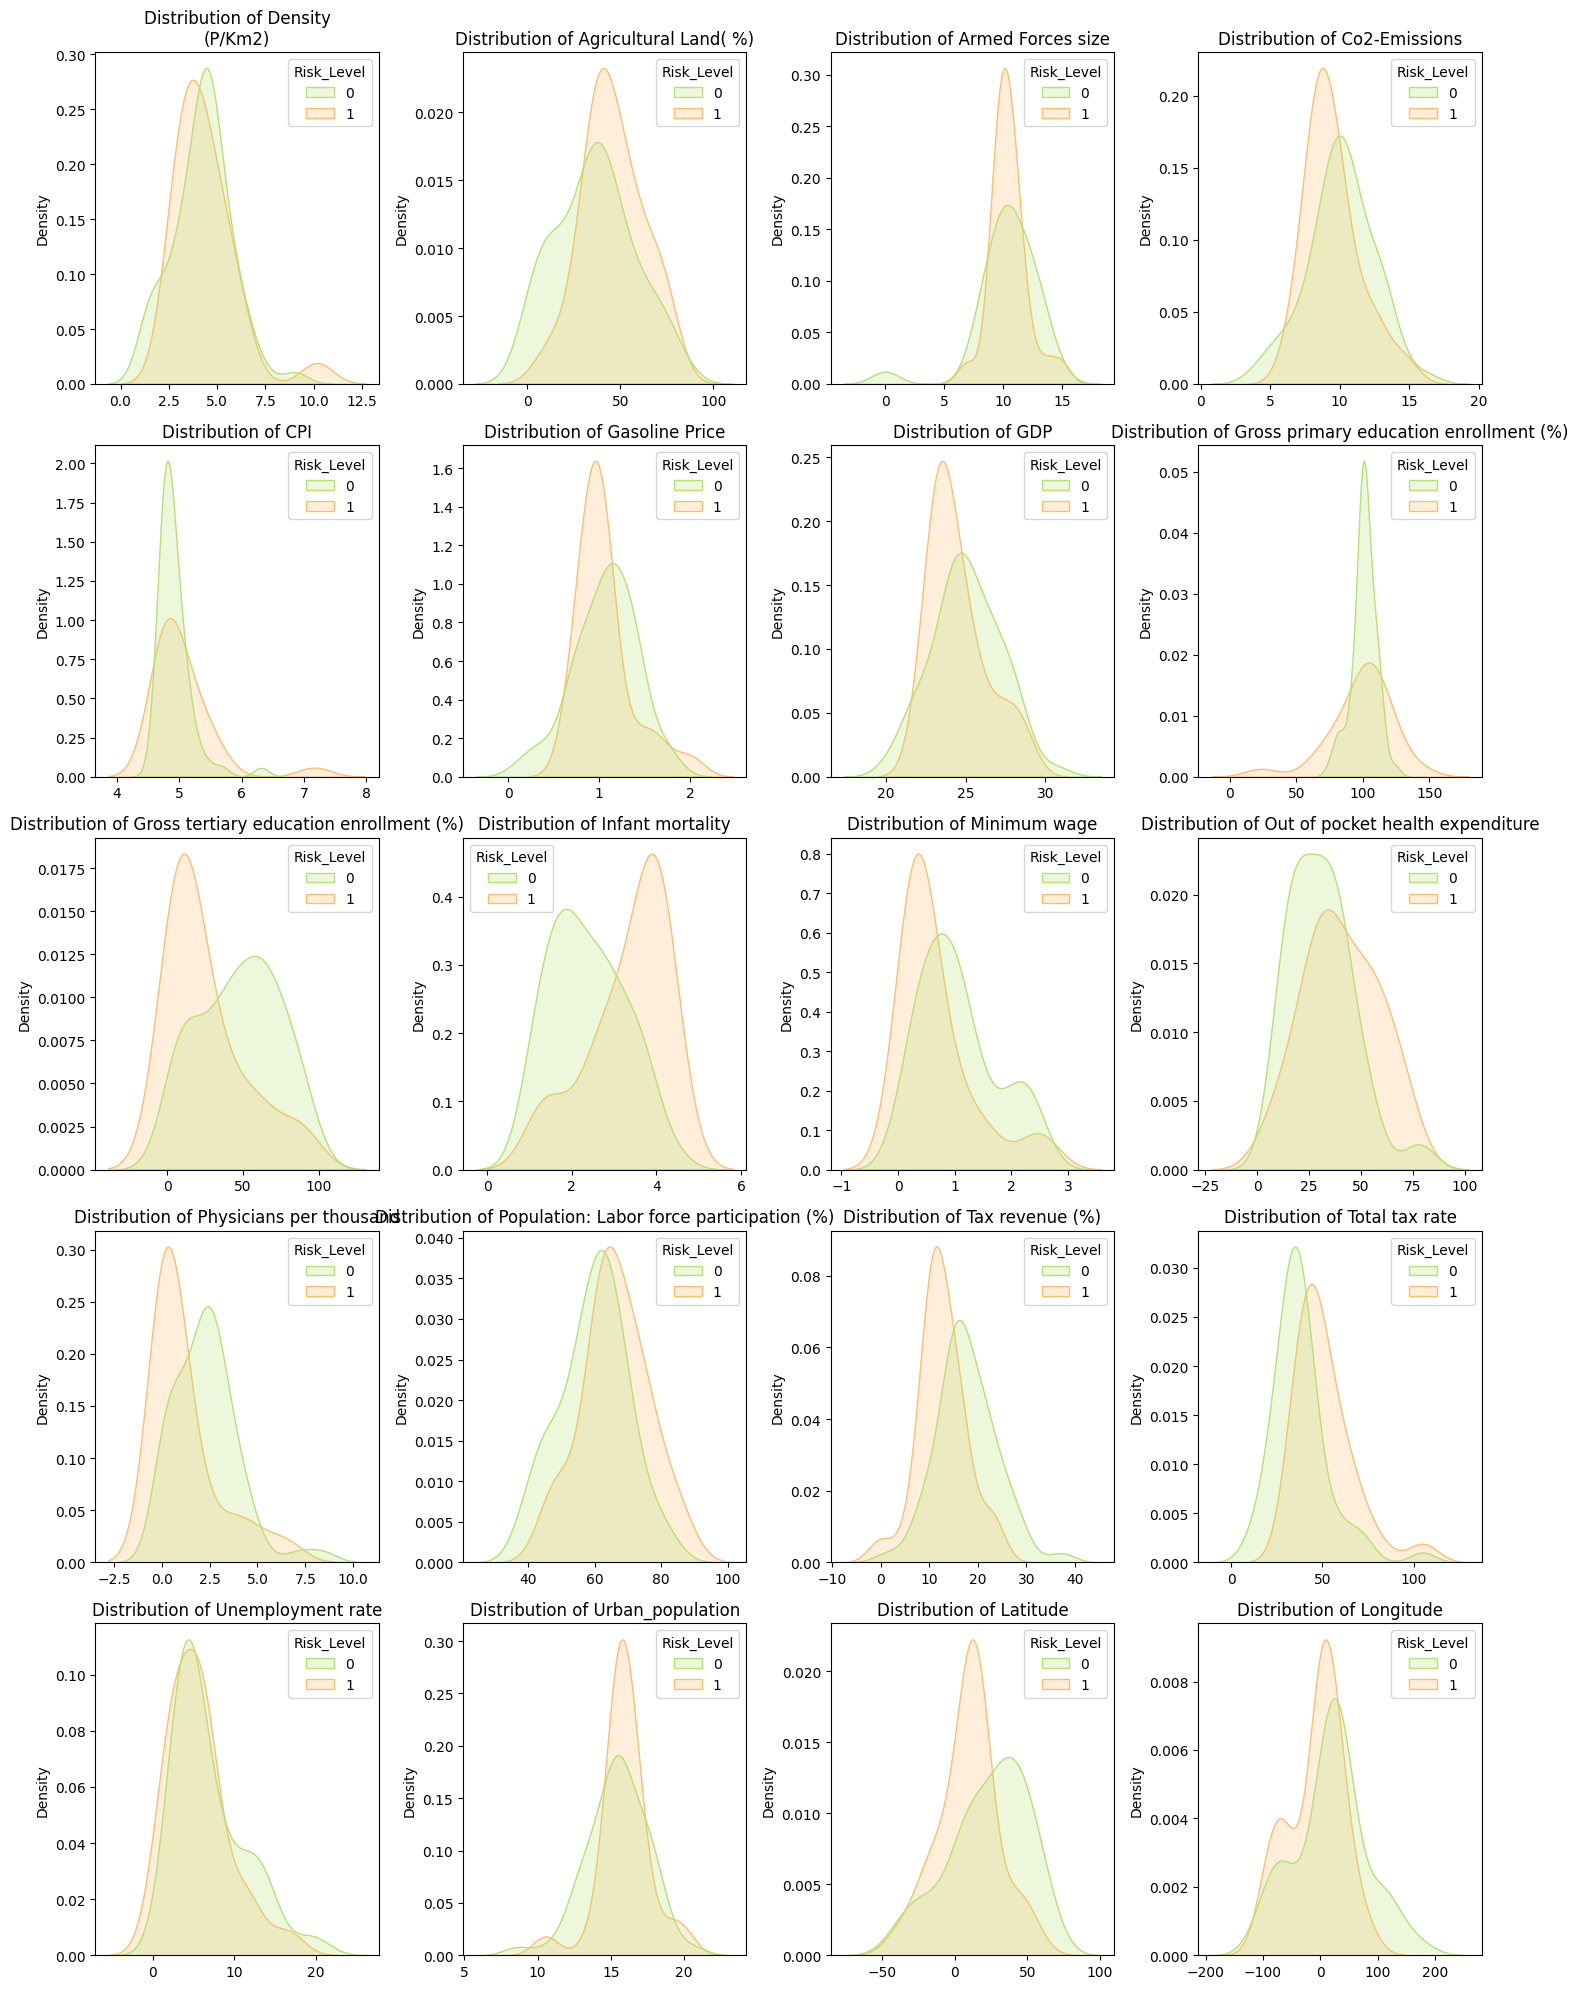

In [8]:
import math

# Combine X_train and y_train for plotting
plot_df = X_train.copy()
plot_df['Risk_Level'] = y_train

# Get list of features
features = X_train.columns
n_features = len(features)
rows = math.ceil(n_features / 4)

# Create the Grid
fig, axes = plt.subplots(rows, 4, figsize=(15, rows * 4))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.kdeplot(
        data=plot_df,
        x=col,
        hue='Risk_Level',
        fill=True,
        palette='RdYlGn_r',
        common_norm=False,
        ax=axes[i]
    )
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('')

# Remove empty subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

The initial analysis of the 20 feature distributions reveals that most individual variables exhibit significant overlap between classes of risk levels. This suggests that no single variable can solve the classification problem alone.

**Key Observations**

* Variables such as Gross Tertiary Education Enrollment, Infant Mortality, and Physicians per Thousand show the clearest displacement of peaks. These features likely carry the highest "Information Gain" to feed to models.
* Longitude, Physicians per Thousand, and Minimum Wage exhibit multiple peaks. This confirms that our classes most likely have sub-groups of countries (e.g., geographic clusters or distinct economic structures) within the same risk category.
* Features like Unemployment Rate, Density, and Agricultural Land (%) show nearly identical distributions for both classes. In a univariate sense, these are "weak" predictors.

Before fitting LDA, it is good practice to check for multicollinearity. One of LDA's core assumptions is that features are not highly correlated — multicollinearity affects the stability of the within-class scatter matrices and can cause numerical issues when LDA computes its inverse.

A correlation audit is performed using a threshold of |r| > 0.80. Any pair above that threshold is flagged for removal, with self-correlations filtered out to avoid false positives.

In [9]:
# Calculate the correlation matrix for X_train
correlation_matrix = X_train.corr()

# Create a list of highly correlated pairs (|r| > 0.80)
high_corr = correlation_matrix.unstack()
high_corr = high_corr[abs(high_corr) > 0.80]
high_corr = high_corr[high_corr < 1] # Remove self-correlation

print("Highly Correlated Pairs to Investigate:")
print(high_corr.sort_values(ascending=True).drop_duplicates())

Highly Correlated Pairs to Investigate:
Gross tertiary education enrollment (%)  Infant mortality   -0.856807
Co2-Emissions                            Urban_population    0.822963
                                         GDP                 0.918253
dtype: float64


To decide which variable to drop from each correlated pair, the KDE distributions are used as a guide — the variable with better class separation and a more Gaussian shape is retained.

In our correlation audit, CO2-Emissions exhibited high collinearity with both GDP ($r=0.91$) and Urban_population ($r=0.82$). Since CO2 emissions are an industrial byproduct heavily dictated by economic output and population size, the variable was considered redundant. We chose to retain GDP and Urban_population as they represent more direct socio-economic pressures on land use, while removing CO2-Emissions to ensure the numerical stability of the LDA covariance matrices.

Secondly, a high inverse correlation ($r = -0.85$) was identified between Infant Mortality and Gross Tertiary Education Enrollment. We retained Infant Mortality because its class-conditional distributions show a more Gaussian structure with distinct, well-separated means — Tertiary Education showed two peaks per class, making it less stable and a worse fit for LDA's probabilistic assumptions.

In [10]:
# Train : drop co2.emissions and Gross Tertiary Education Enrollment
X_train.drop(columns=['Co2-Emissions', 'Gross tertiary education enrollment (%)'], inplace=True)

# Test : drop co2.emissions and Gross Tertiary Education Enrollment
X_test.drop(columns=['Co2-Emissions', 'Gross tertiary education enrollment (%)'], inplace=True)

After dropping the highly correlated features (CO2-Emissions and Gross Tertiary Education), we ran a second correlation audit to verify the "cleanliness" of the data. The second audit returned no results, which is exactly what we wanted. It proves that our "surgery" worked and there are no longer any feature pairs with a correlation above $|r| > 0.80$. This outcome confirms that every variable left in the model now provides unique, independent information. We aren't "double-counting" the same socio-economic trends.

In [11]:
# create a second revision on the correlation matrix
correlation_matrix_2 = X_train.corr()

# Create a list of highly correlated pairs (|r| > 0.80)
high_corr = correlation_matrix_2.unstack()
high_corr = high_corr[abs(high_corr) > 0.80]
high_corr = high_corr[high_corr < 1] # Remove self-correlation

print("Highly Correlated Pairs to Investigate:")
print(high_corr.sort_values(ascending=True).drop_duplicates())

Highly Correlated Pairs to Investigate:
Series([], dtype: float64)


With the correlated features removed, the next step is to apply `StandardScaler()` to the data. LDA is sensitive to feature scale — variables measured in large units (e.g., population size) would otherwise dominate the scatter matrices over variables measured in small units (e.g., physicians per thousand). Scaling ensures every feature contributes on equal footing.

Note: the scaler is **fit only on `X_train`** and then applied to both sets, preventing any data leakage from the test set.

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Before fitting the final model, a baseline LDA is run on the full scaled training data. This serves two purposes:

1. **Understand the discriminant weights ($w$):** the scalings reveal which variables the model leans on most. If Infant Mortality has a weight of 2.5 and GDP has a weight of 0.1, the model is effectively ignoring GDP — a strong signal for feature pruning.
2. **Visual separability check:** plotting the LD1 scores shows whether the two classes form distinct clusters or still overlap significantly, guiding further cleaning if needed.

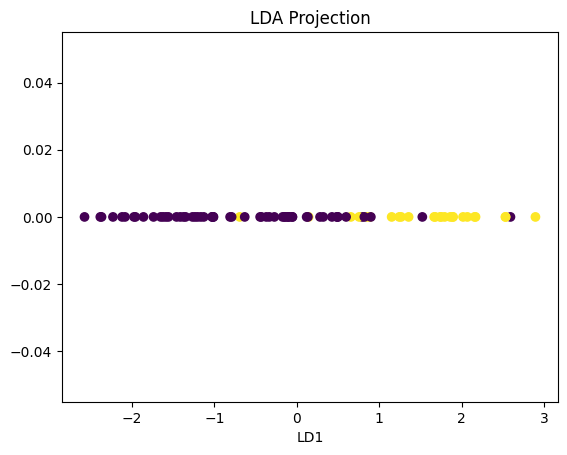

In [13]:
# initialize the LDA
lda = LinearDiscriminantAnalysis()

# fit LDA
lda.fit(X_train_scaled, y_train)

# visualize the discriminants
X_lda = lda.transform(X_train_scaled)
plt.scatter(X_lda[:, 0], np.zeros_like(X_lda[:, 0]), c=y_train)
plt.title('LDA Projection')
plt.xlabel('LD1')
plt.show()

To investigate the slight overlap seen in the LD1 projection, the discriminant weights (scalings) are extracted from the baseline model. `lda.scalings_` contains the coefficient each feature received in the new LD1 equation — the higher the absolute weight, the more that variable contributes to separating the two classes.

The features are sorted by absolute weight in both directions to identify the **top discriminators** (candidates to keep) and the **least discriminating variables** (candidates for pruning).

In [14]:
# Extract scalings and put them in a DataFrame
scalings = pd.DataFrame(lda.scalings_, index=X_train.columns, columns=['LD1'])

# Sort by absolute value
scalings['Abs_Weight'] = scalings['LD1'].abs()
scalings_sorted = scalings.sort_values(by='Abs_Weight', ascending=False)
scalings_sorted_down = scalings.sort_values(by='Abs_Weight', ascending=True)

print("Top Discriminatory Variables:")
print(scalings_sorted[['LD1']].head(7))

print("\nLeast Discriminatory Variables:")
print(scalings_sorted_down[['LD1']].head(7))

Top Discriminatory Variables:
                                                LD1
Infant mortality                           1.456415
Minimum wage                               0.624716
Urban_population                           0.551531
Population: Labor force participation (%)  0.519285
Longitude                                 -0.489309
Physicians per thousand                    0.405828
Density\n(P/Km2)                           0.394014
/nLeast Discriminatory Variables:
                                             LD1
Gross primary education enrollment (%) -0.044174
Unemployment rate                      -0.070120
Latitude                                0.141279
GDP                                    -0.163004
Out of pocket health expenditure        0.172323
Total tax rate                          0.177278
Agricultural Land( %)                   0.209706


The baseline LDA fit revealed a clear hierarchy of importance among the variables:

* **Primary driver — Infant Mortality** ($w = 1.46$): its high positive weight confirms that lower levels of basic social development are the strongest single indicator of deforestation risk.
* **Secondary drivers** — Minimum Wage ($0.62$), Urban Population ($0.55$), and Labor Force Participation ($0.52$) represent the demographic and economic pressures on land use.
* **Longitude** ($-0.49$) adds a meaningful geographic component, suggesting risk is regionally clustered rather than randomly distributed.

To improve simplicity and reduce overfitting, features with near-zero weights are removed: **Gross Primary Education Enrollment** ($w = -0.04$) and **Unemployment Rate** ($w = -0.07$) provide no lift to the discriminant function. Additionally, **GDP** ($w = -0.16$) and **Latitude** ($w = 0.14$) fall below the $|w| < 0.15$ stability threshold and are also dropped. Reducing the number of features relative to our sample size makes the LDA covariance matrix more robust and focuses the model on its strongest signals.

In [15]:
# Drop
X_train_reduced = X_train.drop(columns=['Gross primary education enrollment (%)', 'Unemployment rate', 'GDP', 'Latitude'])
X_test_reduced = X_test.drop(columns=['Gross primary education enrollment (%)', 'Unemployment rate', 'Latitude', 'GDP'])

# Re-scaling the reduced feature set
scaler = StandardScaler()

X_train_cleaned = scaler.fit_transform(X_train_reduced)
X_test_cleaned = scaler.transform(X_test_reduced)

print(f"Features reduced from {X_train.shape[1]} to {X_train_reduced.shape[1]}")

Features reduced from 18 to 14


In [16]:
# Initialize and Fit
lda_opt = LinearDiscriminantAnalysis()
lda_opt.fit(X_train_cleaned, y_train)

# Predictions
y_pred = lda_opt.predict(X_test_cleaned)

# Metrics
print("--- Optimized LDA Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

--- Optimized LDA Performance ---
Accuracy: 0.8571
Precision: 0.8000
Recall: 0.6667
F1-Score: 0.7273

Confusion Matrix:
[[14  1]
 [ 2  4]]


**Metric Breakdown**

Accuracy (86%) and Precision (80%) are strong, but given the class imbalance they alone don't tell the full story. The more important metric in this domain is **Recall (67%)** as it tells us how many truly critical deforestation countries were actually caught. A False Negative here means a high-risk area goes undetected and untreated, which carries a much higher ecological cost than a False Positive. The F1-Score (0.73) reflects a reasonable but imperfect balance between the two. The ROC curve below provides a more complete picture of the model's discriminating power across all thresholds.

**Confusion Matrix Breakdown:**

The matrix `[[14, 1], [2, 4]]` tells us that out of 21 test countries:
- **14 True Negatives**: Non-critical countries correctly identified as safe — the model is very reliable here.
- **4 True Positives**: High-risk countries correctly flagged.
- **1 False Positive**: One safe country was unnecessarily flagged — a low-cost error (the forest simply gets an extra check).
- **2 False Negatives**: Two critical deforestation countries were missed entirely. In an environmental context these are the most dangerous errors — a high-risk region goes untreated.

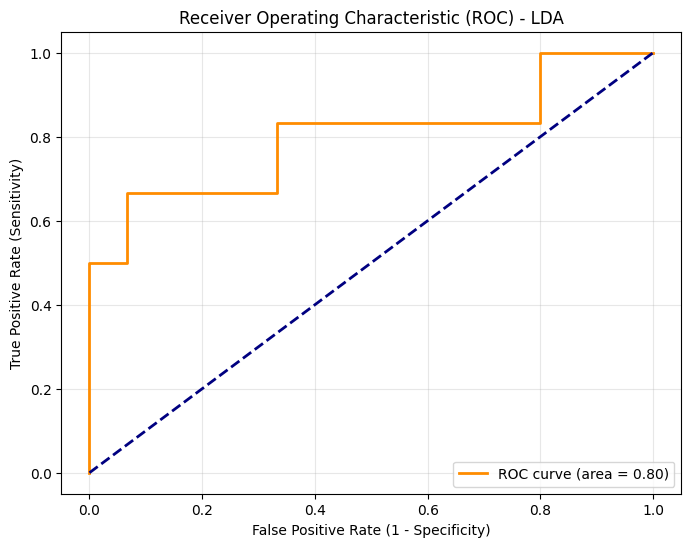

In [17]:
# ROC Curve (The proof of multivariate power)
y_probs = lda_opt.predict_proba(X_test_cleaned)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) - LDA')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

**ROC Curve (AUC = 0.80):**
The ROC curve confirms the model has good discriminating power well above the random baseline (the dashed diagonal). The step-like shape is expected with small test sets and does not indicate a problem with the model. An AUC of 0.80 means that in 80% of random pairings between a critical and a non-critical country, the model correctly ranks the critical one higher — a solid result for a linear model on 21 test samples.

Overall the LDA model generalizes well, remains interpretable, and the multivariate combination of 14 features clearly outperforms any single variable. The main limitation is sensitivity to the minority class, a known challenge when working with small, imbalanced datasets.

# Decision Tree

To complement LDA and compare two different classification approaches, a Decision Tree is applied to the same dataset. Two key differences from the LDA pipeline are intentional:

- **No StandardScaler:** Decision Trees split on thresholds, not distances, so feature scale has no effect on the result.
- **No multicollinearity removal:** Trees are greedy — if two variables are 90% correlated, the algorithm will simply pick the one that produces the best split and ignore the other. Manual pruning is unnecessary.

The first step is to train an unconstrained "wild" tree (`max_depth=None`) to establish a baseline and expose overfitting. Accuracy and F1-Score on both train and test sets are reported to quantify the variance problem before moving to hyperparameter tuning.

In [20]:
#  Initialize the "Wild" Tree
dt_wild = DecisionTreeClassifier(random_state=42)

# Fit on the SAME data used for LDA
dt_wild.fit(X_train, y_train)

# Check for Overfitting
train_acc = dt_wild.score(X_train, y_train)
test_acc = dt_wild.score(X_test, y_test)
train_f1_score = f1_score(y_train, dt_wild.predict(X_train))
test_f1_score = f1_score(y_test, dt_wild.predict(X_test))

print(f"Wild Tree Training Accuracy: {train_acc:.4f}")
print(f"Wild Tree Test Accuracy: {test_acc:.4f}")
print(f"Wild Tree Training F1-Score: {train_f1_score:.4f}")
print(f"Wild Tree Test F1-Score: {test_f1_score:.4f}")

Wild Tree Training Accuracy: 1.0000
Wild Tree Test Accuracy: 0.7143
Wild Tree Training F1-Score: 1.0000
Wild Tree Test F1-Score: 0.4000


The baseline Decision Tree exhibits classic **High Variance** — a perfect training accuracy of $1.0$ collapses to $0.71$ on the test set, and the F1-Score drops from $1.0$ to $0.40$. The model memorized the training data, creating overly specific leaf nodes that capture noise rather than signal. The low F1 on the test set tells us it struggles particularly with the minority class (High Risk), defaulting too often to the safe majority prediction.

To address this, the next steps are Hyperparameter Tuning and pruning to constrain the tree's complexity and improve generalization.

Before tuning, a feature importance analysis is run on the wild tree using `feature_importances_` (Gini-based). This gives us a first look at which variables the tree relied on most, and lets us compare against the LDA scalings.

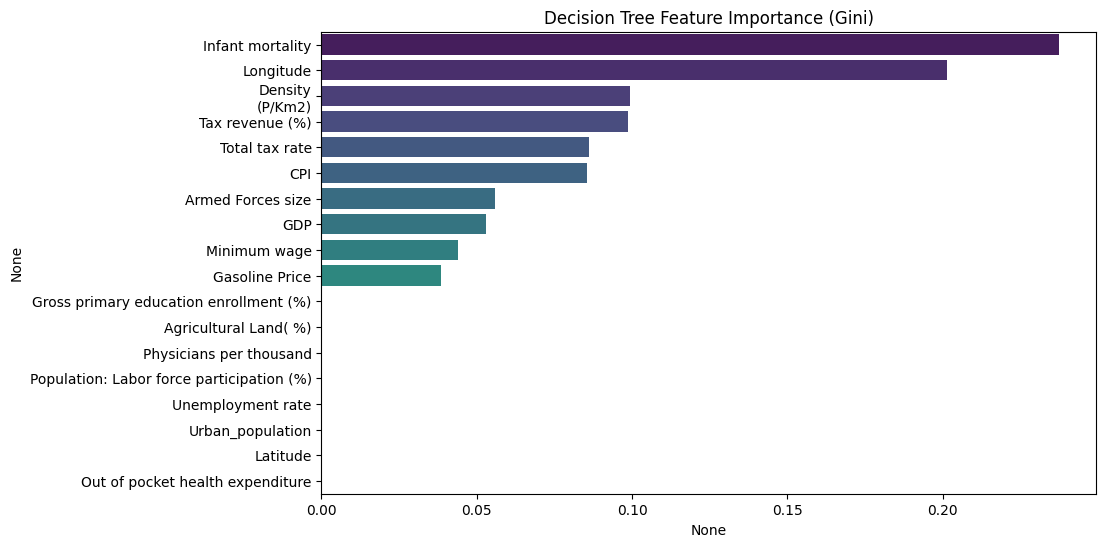

In [24]:
# Extract importances
importances = pd.Series(dt_wild.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=importances.index, hue=importances.index, dodge=False, palette='viridis', legend=False)
plt.title('Decision Tree Feature Importance (Gini)')
plt.show()

Just as the LDA scalings showed, **Infant Mortality dominates** the Gini importance chart by a large margin — confirming it is a universal predictor for deforestation risk regardless of algorithm. Features at the bottom (e.g., Primary Education Enrollment) contribute zero importance, meaning the tree never used them for any split. Both models independently agree on the same primary driver, which strongly validates the signal.

To improve the model, hyperparameter tuning is performed to constrain tree complexity and prevent overfitting. The parameter grid to search over is:

| Parameter | Values |
|---|---|
| `max_depth` | 3, 5, 10 |
| `min_samples_split` | 2, 5, 10 |
| `min_samples_leaf` | 1, 2, 5 |

These ranges are informed by Bhuva (2025) for datasets of this size. `GridSearchCV()` automates the search by evaluating all combinations with **5-fold cross-validation** — the model is trained and scored 5 times on different data folds, giving a more reliable estimate of generalization performance than a single train-test split.

In [26]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini'], 
}
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)
# print the accuracy 
print(f"Best Cross-Validated Accuracy: {grid_search.best_score_:.4f}")

Best parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 10}
Best Cross-Validated Accuracy: 0.7316


The grid search returned `max_depth=3`, `min_samples_split=10`, and `min_samples_leaf=2`. Each parameter has a clear interpretation:

- **`max_depth=3`:** Simpler, shallower trees generalize better. Limiting depth to 3 forces the model to rely on broad, robust patterns rather than memorizing specific cases.
- **`min_samples_split=10`:** The tree cannot create a new branch unless at least 10 countries support it, preventing custom rules built around outliers.
- **`min_samples_leaf=2`:** No final prediction can rest on a single data point, ensuring every leaf node represents a small but stable group.

One important distinction from the LDA pipeline: the Decision Tree requires **no manual feature elimination**. Unlike LDA, which needs pruning to maintain matrix stability, the tree performs implicit feature selection — the Gini importance analysis showed that variables like Unemployment Rate and Latitude were naturally assigned zero weight. The model's greedy splitting criteria neutralized the noise without any manual intervention.

In [28]:
# Initialize with the best parameters
dt_final = DecisionTreeClassifier(
    criterion='gini', 
    max_depth=3, 
    min_samples_leaf=2, 
    min_samples_split=10, 
    random_state=42
)

# Fit and Predict
dt_final.fit(X_train, y_train)
y_pred_final = dt_final.predict(X_test)

# chck the classification report
print("\nFinal Classification Report:")
print(classification_report(y_test, y_pred_final))

Final Train F1: 0.7727
Final Test F1: 0.2500
Final Train Accuracy: 0.8780
Final Test Accuracy: 0.7142857142857143

Final Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.93      0.82        15
           1       0.50      0.17      0.25         6

    accuracy                           0.71        21
   macro avg       0.62      0.55      0.54        21
weighted avg       0.67      0.71      0.66        21



## Decision Tree: Classification Report & Tree Analysis

### Classification Report

After hyperparameter tuning (`max_depth=3`, `min_samples_split=10`, `min_samples_leaf=2`), the pruned Decision Tree shows that the most critical number here is the Recall of 0.17 for High Risk because out of 6 truly critical countries in the test set, the model only caught 1. That means 5 high-risk deforestation zones went undetected; a result that would be unacceptable in a real-world environmental application. The Train F1 of 0.7727 versus Test F1 of 0.2500 also reveals that despite pruning, the model still fails to generalize to the minority class.

**Why did pruning hurt recall so much?** Forcing `max_depth=3` simplifies the tree to just 3 layers of splits. For the majority class (Low Risk), 3 layers are more than enough — it can rely on broad patterns. But the minority class (High Risk) often lives in smaller, more specific corners of the feature space that get cut off when depth is restricted. The result is a conservative model that defaults to "Low Risk".

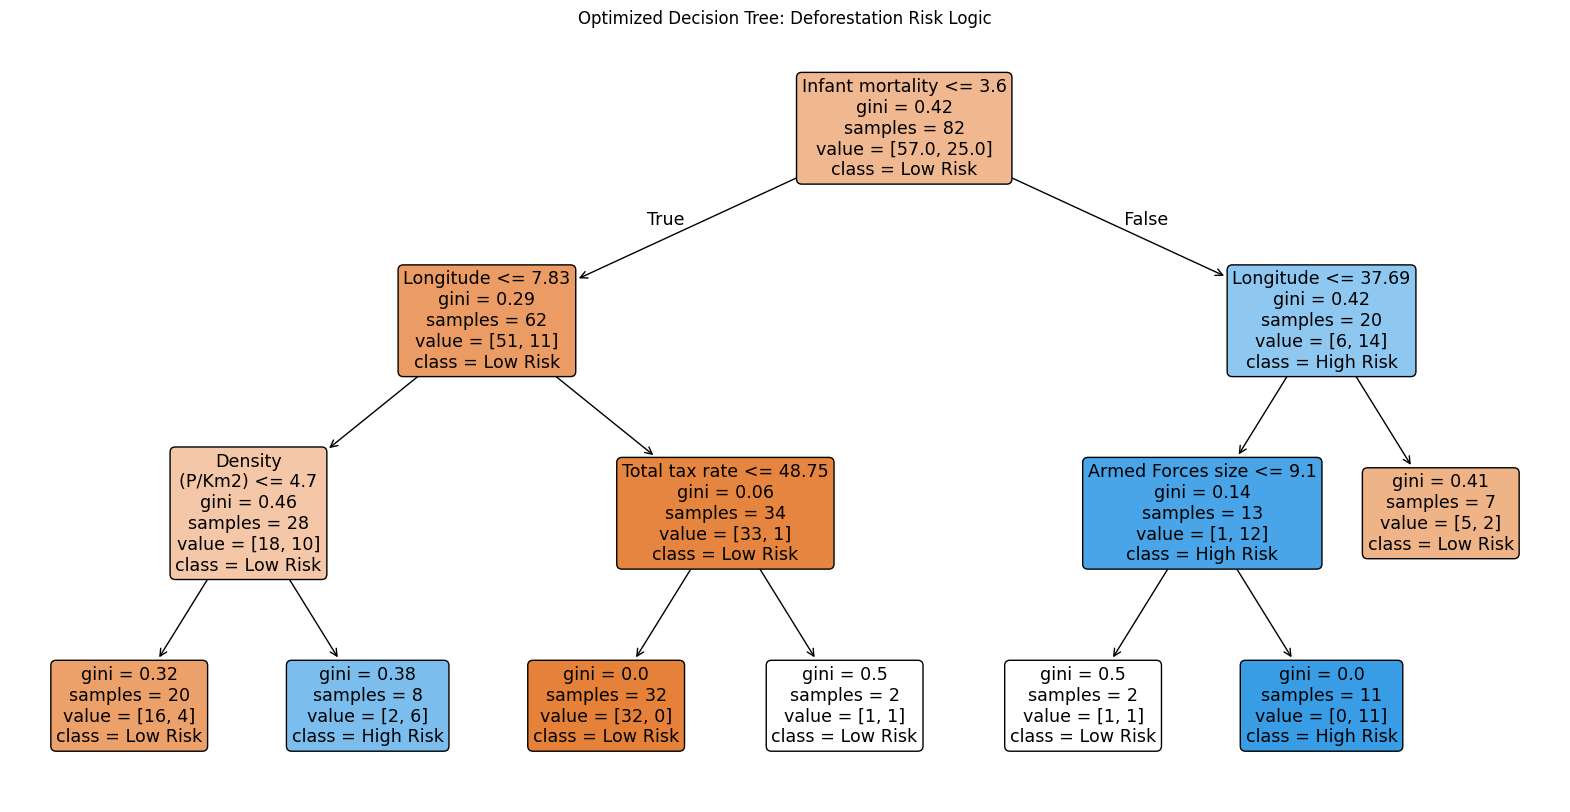

In [29]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(dt_final, 
          feature_names=X_train.columns, 
          class_names=['Low Risk', 'High Risk'], 
          filled=True, rounded=True, precision=2)
plt.title("Optimized Decision Tree: Deforestation Risk Logic")
plt.show()

**Visual Decision Tree Analysis**


**Root Split**
We find that onifant mortality is the single most powerful split, cleanly dividing the 82 training samples into two very different populations:
* True: Low-mortality countries so predominantly developed nations lean heavily Low Risk.
* False: High-mortality countries lean strongly High Risk 

**Depth 2**
- On the Low-Mortality branch longitude appears and seems to separate Western/European countries (mostly safe, low gini) from more eastern ones where a secondary split is needed.
- On the High-Mortality branch we can infer that longitud seems to be isolating Sub-Saharan African and South/Southeast Asian regions, which concentrate the highest deforestation risk. 

**Depth 3**
- Density: Very sparse, low-mortality countries still carry elevated risk. This may reflect vast, sparsely governed forested areas that are harder to monitor and protect.
- Total tax rate: This near-pure node [32, 0] captures a very clean Low Risk cluster; whihs allows us to get that countries with low mortality, eastern longitude, and moderate-to-high tax rates are essentially never critical for deforestation.
- Armed Forces size: Used on the high-risk branch; larger state capacity slightly modulates risk classification within an already high-risk population.

# Final Analysis

## Comparison LDA vs Decision Tree... Which is better?
As always, this question is contextual. For this specific project, it depends heavily on predictability versus interpretability. As of now, the Decision Tree and the LDA seem to demonstrate very varied and different possibilities. One has great metrics (the LDA), as it shows good accuracy but also precision, and we can even modify it a little further to allow for more false positives (FP) than false negatives (FN) (which is already the case, but we could make it more dramatic). While the Decision Tree has very low predictive power, we can see that there is a lot of behavioral understanding we get from this, such as clearly seeing the impact of infant mortality.

So, what is the final verdict? It depends. Right now, if we are looking for predictive power, the LDA works as a stronger tool, as it successfully created a clear "Risk Axis" (LD1), making it highly reliable for flagging countries as long as the data is clean. However, if we were NGO officials or stakeholders trying to understand the behavior to create specific tools for further action and alarm systems (other real-world tools, not models), it is extremely useful to look at a depth-3 tree and instantly understand the "Tipping Points" (e.g., “If Infant Mortality drops below X, and Density is below Y, the risk goes away...”).

## Key Takeaways (Beyond Infant Mortality)
We already know Infant Mortality is the #1 predictor for risk (representing basic social development). But other key takeaways were uncovered, such as:

1. The LDA proved that variables overlapping in univariate KDE plots became highly separable when combined. Risk isn't just about poverty; it’s the dangerous combination of low development, high population density, and specific geographic locations.
2. Variables like Latitude and Longitude consistently survived feature selection. This proves that global deforestation risk isn't evenly distributed—it is highly localized to specific tropical and subtropical coordinates (affected by climates, the governments in the areas, etc.).
3. While the LDA saw variables like GDP or Minimum Wage as linear drivers, the Decision Tree treated them as "Thresholds." This suggests that economic growth doesn't linearly decrease risk; rather, a country must cross a specific economic "hurdle" before environmental preservation becomes a priority. It acts as an aider, but not as a linear predictor feature.

## Further improvements
In the case of this analysis, we can do several things to improve the LDA. For instance, we can be less decisive and use 3 classes instead of 2; this can capture more of the differences and put the outliers into a kind of class of their own. By introducing a "Medium Risk" or "Transitional" class, the LDA could better isolate the extreme outliers and provide a smoother risk gradient.

Currently, the LDA uses a default 50% probability threshold to assign risk. In the future, we could shift this decision boundary (e.g., to 30%) to intentionally increase false positives (false alarms) in exchange for minimizing false negatives (missed deforestation). Finally, since a single Decision Tree struggles with predictive power compared to the LDA, the natural next step is to upgrade to a Random Forest or Gradient Boosting (XGBoost) model. This combines hundreds of shallow trees, keeping the non-linear logic but achieving massive boosts in accuracy and F1-score. 

Lastly, a possible further work that requires more of a pre-work, but we can consider getting time series (over the years) data or finding the data for the dropped countries that at the beggining had nulls or too many disbalances, even if its through some methodology of self filling the variables (thorugh research) to be able to have more data to train and work on.

Referencs:
1. https://medium.com/@lomashbhuva/understanding-decision-trees-and-hyperparameter-tuning-in-machine-learning-c0a4467a1e69